# Detecting Crop Disease from Leaf Images


## Importing the Library


In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

## Connecting to Google Drive

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Augmentation (Preparing the data)

In [3]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

In [4]:
train_set = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Dataset",
    target_size = (150, 150),
    batch_size = 32,
    class_mode = "sparse",
    subset = "training"
    )

Found 1738 images belonging to 3 classes.


In [5]:
val_set = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Dataset",
    target_size = (150, 150),
    batch_size = 32,
    class_mode = "sparse",
    subset = "validation",
    shuffle = False
    )

Found 433 images belonging to 3 classes.


## Building the model

In [6]:
from tensorflow.keras import models, layers

**1st layer**
- filters/kernel -> 3*3 pixel filter and this is the kernel size.
- we will create 32 filter hare. filter works differently. but the basic work is to scan.
* 1st filter -> where is vein
* 2nd filter -> how much age
* 3rd filter -> is there any prominent color (brown)
and so on..

activation relu:
* if 1st filter get the negetive value. means he is unable to find patteren. then the information will not pass to the 2nd stage.

input shape:
* all image convert into 150 to 150 pixel and RGB(3) color format. so that we can scan better.

Maxpulling:
* after the filter we create the layer. later in maxpulling we again filter with 2*2 filter. By this avoid the unnecessery information.

* As the image is more or less same thats why we create many layers. if we just want to differentiate just the cat and dog. 2 layer will be enough.

!!! find out why more is bad....

In [7]:
model = models.Sequential([
    # Layer-1: Detects basic edges and the veins of the leaf
    layers.Conv2D(filters=32, kernel_size = (3, 3), activation = 'relu', input_shape=(150, 150,3)),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Layer 2: Detects color blobs and spot pattern
    layers.Conv2D(filters=64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Layer 3: Complex shapes (like the halo around a fungus spot)
    layers.Conv2D(filters=128, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2, 2)),

    # Flatten the 2D image into a 1D line to take the final decision
    layers.Flatten(),
    layers.Dense(units = 128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(units = 3, activation = 'softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Compliling the model

In [9]:
model.compile(
    optimizer='adam', # apaptive moment optimizer is an algorithm which work wt. loss and wt. gain process give importance to those feature.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

## Training the model

In [10]:
history = model.fit(
    train_set,
    epochs=10,
    validation_data=val_set
    )

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - accuracy: 0.6835 - loss: 0.7261 - val_accuracy: 0.8453 - val_loss: 0.3866
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8441 - loss: 0.3828 - val_accuracy: 0.8430 - val_loss: 0.3203
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8792 - loss: 0.2962 - val_accuracy: 0.8776 - val_loss: 0.3304
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9102 - loss: 0.2326 - val_accuracy: 0.9192 - val_loss: 0.2074
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9171 - loss: 0.2149 - val_accuracy: 0.9584 - val_loss: 0.1076
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9229 - loss: 0.1964 - val_accuracy: 0.8753 - val_loss: 0.3188
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9298 - loss: 0.1898 - val_accuracy: 0.9561 - val_loss: 0.1204
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9551 - loss: 0.1340 - val_accuracy: 0.9561 - v

## Ploting the learning curve (Model Evaluation)

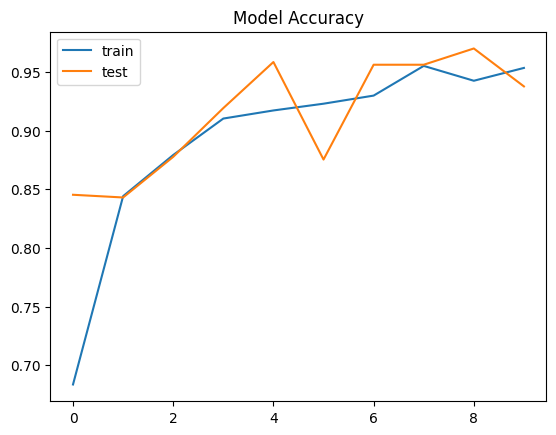

In [11]:
# Learning curve
# Plot Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.legend()
plt.show()

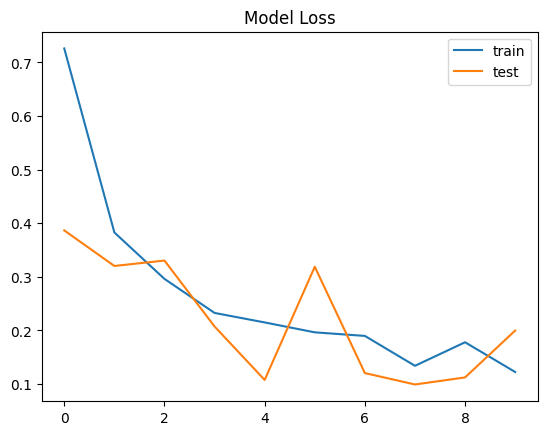

In [12]:
# Plot Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.legend()
plt.show()

## Saving the model

In [13]:
model.save("potato_leaf_disease_model.keras")

## Re-using the AI brain

In [14]:
from tensorflow.keras.models import load_model

In [17]:
AI_brain = load_model("/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/potato_leaf_disease_model.keras")

## AI Brain Evaluation

### Model Loss and Acuracy

In [18]:
loss, accuracy = AI_brain.evaluate(val_set)
print(f"AI brain loss on validation set: {loss:.4f}")
print(f"Ai brain accuracy on validation set: {accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 877ms/step - accuracy: 0.9238 - loss: 0.2336
AI brain loss on validation set: 0.2336
Ai brain accuracy on validation set: 0.9238


### Confusion Matrix

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
# 1. Critical: Teset the generator so it sarts from the first image
val_set.reset()

# 2. Ask the model to predict every image in the validation folder
print("Generating predictions... this might take some time")
predictions = AI_brain.predict(val_set)    # to show np.set_printoptions(suppress=True) then print(predictions)

# 3. Softmax activation function gives probabilities
# np.argmax picks the index  of the highest value
predicted_classes = np.argmax(predictions, axis=1)

# 4. Grab the actual class
true_classes = val_set.classes

# 5. Grab the folder name to use as labels
class_label = list(val_set.class_indices.keys())

# 6. Create the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

Generating predictions... this might take some time
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 873ms/step
[[199   0   1]
 [  3  28   2]
 [ 26   2 172]]


### Ploting the confusion metrics

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

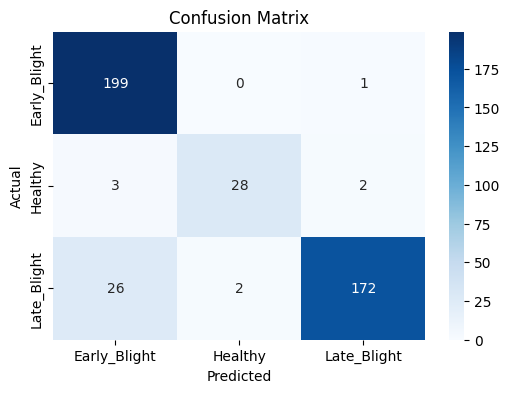

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot = True, fmt= "d", cmap = "Blues", xticklabels=class_label, yticklabels=class_label)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Predicting a single prediction

In [23]:
from tensorflow.keras.preprocessing import image

In [24]:
def predict_plant_disease(image_path, model):
  #Data Augmentation
  img = image.load_img(image_path, target_size=(150, 150))
  img_array = image.img_to_array(img)
  img_array = img_array/255.0
  img_array = np.expand_dims(img_array, axis=0)

  #rediction
  predictions = model.predict(img_array)
  class_labels = ["Early Blight", "Healthy", "Late Blight"]

  winning_index = np.argmax(predictions[0])
  predicted_disease = class_labels[winning_index]
  confidence = predictions[0][winning_index] * 100

  #Display the image and the AI's diagnosis
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"AI Diagnosis: {predicted_disease}\nConfidence: {confidence:.2f}%")
  plt.show()


### Test image 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


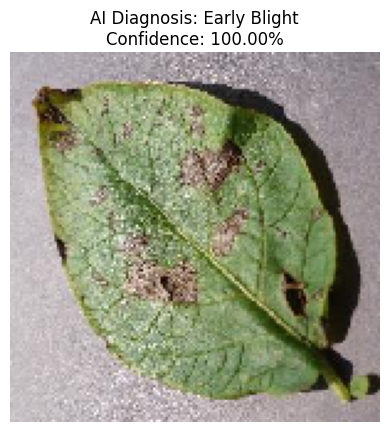

In [25]:
# Upload a new leaf photo to your Colab session or point it to your Drive
my_test_image = '/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Test_Image_1.JPG'

# Call the function using your reused_model
predict_plant_disease(my_test_image, AI_brain)

### Test image 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


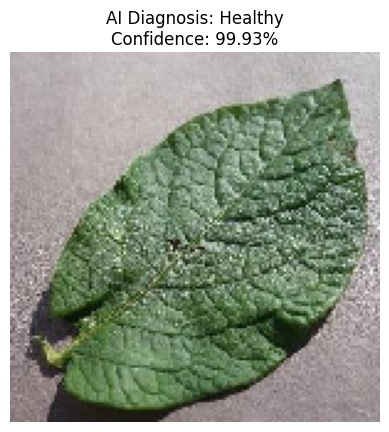

In [26]:
# Upload a new leaf photo to your Colab session or point it to your Drive
my_test_image = '/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Test_Image_2.JPG'

# Call the function using your reused_model
predict_plant_disease(my_test_image, AI_brain)

### Test image 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


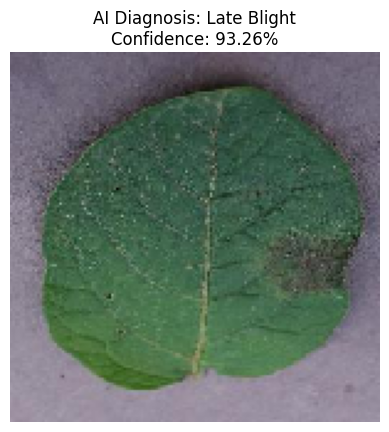

In [27]:
# Upload a new leaf photo to your Colab session or point it to your Drive
my_test_image = '/content/drive/MyDrive/NBICT LAB PDSML-B-8/8. Plant Disease Detection/Test_Image_3.JPG'

# Call the function using your reused_model
predict_plant_disease(my_test_image, AI_brain)